# 🔍 AML Detection — AML Feature Engineering FINAL Notebook

**Dataset:** SAML-D (Synthetic Anti-Money Laundering Dataset)  
**Target:** `Is_laundering`

Notebook ini fokus pada peningkatan **PR-AUC, Recall, dan F1** tanpa membuat model salah secara metodologi.

## Prinsip metodologi utama
| Bagian | Keputusan |
|---|---|
| Target | Menggunakan `Is_laundering` |
| Leakage | Drop `Laundering_type`, `Type`, `Is_Suspicious` |
| Account ID | `Sender_account` dan `Receiver_account` tidak di-OneHot sebagai ID mentah |
| Account behavior | Diubah menjadi frequency/count/statistik transaksi berdasarkan **train set saja** |
| Feature engineering AML | `Amount_log`, `CrossBorder`, `CurrencyMismatch`, `Hour`, `DayOfWeek`, `Month`, `IsWeekend` |
| Imbalance | Pakai `class_weight` / `scale_pos_weight`, bukan oversampling test/validation |
| Split | Stratified train/validation/test |
| Threshold | Tuning threshold pada validation set; test set hanya untuk evaluasi final |
| Evaluasi | PR-AUC, ROC-AUC, Precision, Recall, F1, F2, confusion matrix, threshold table |

> Catatan paper: fitur akun dihitung setelah split agar statistik akun dari validation/test tidak bocor ke training. Ini lebih aman daripada membuat frequency encoding dari seluruh dataset sebelum split.


## 0. Install Library yang Dibutuhkan

In [1]:
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn shap psutil joblib

## 1. Import Library & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time
import os
import gc

warnings.filterwarnings('ignore')

try:
    import psutil
except ImportError:
    psutil = None
    print("psutil belum tersedia. Jika perlu memory monitoring, install: pip install psutil")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42

# =============================================
# GANTI PATH INI SESUAI LOKASI FILE CSV KAMU
# Contoh:
# DATASET_PATH = "SAML-D.csv"
# DATASET_PATH = "/content/drive/MyDrive/SAML-D.csv"
# =============================================
DATASET_PATH = "SAML-D.csv"

df = pd.read_csv(DATASET_PATH)

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

display(df.head())


✅ Dataset loaded successfully!
Shape: 9,504,852 rows x 12 columns


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


## 2. Eksplorasi Data (EDA)

In [3]:
# General dataset information
print('=== Dataset Information ===')
print(df.info())
print()

print('=== Column Names ===')
print(df.columns.tolist())

# Check missing values
missing = df.isnull().sum()

print()
print('=== Missing Values ===')
print(missing[missing > 0] if missing.any() else '✅ No missing values found')

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB
None

=== Column Names ===
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']

=== Missing Values ===
✅ No missing value

In [4]:
import os

OUTPUT_DIR = "."  # Simpan di folder notebook
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("PNG files will be saved to:", os.path.abspath(OUTPUT_DIR))

PNG files will be saved to: c:\Users\nelae\Downloads\pencucian_uang_updated (2)\pencucian uang\pencucian uang


Using target column: "Is_laundering"

Class distribution:
  Normal (0): 9,494,979 (99.8961%)
  Suspicious (1): 9,873 (0.1039%)


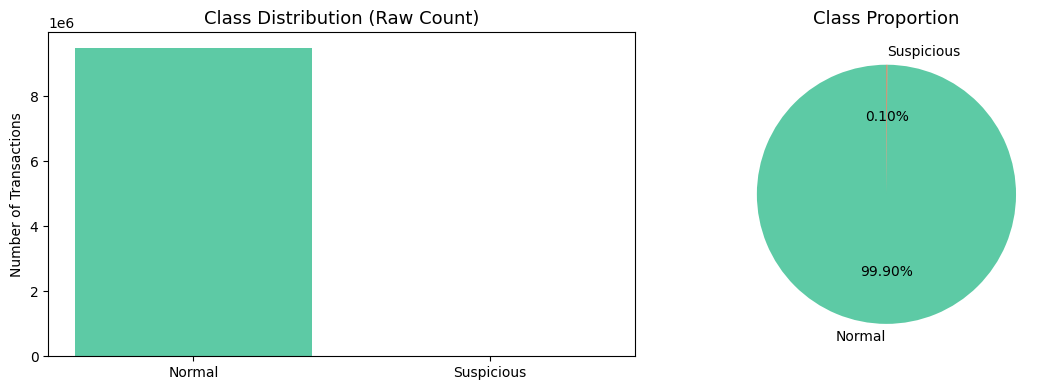

⚠️ The data is highly imbalanced! Ditangani via class_weight di model.


In [5]:
TARGET_COL = 'Is_laundering'
print(f'Using target column: "{TARGET_COL}"')

counts = df[TARGET_COL].value_counts()
pct    = df[TARGET_COL].value_counts(normalize=True) * 100

print(f'\nClass distribution:')
for k in counts.index:
    label = 'Normal' if k == 0 else 'Suspicious'
    print(f'  {label} ({k}): {counts[k]:,} ({pct[k]:.4f}%)')

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#5DCAA5', '#D85A30']

axes[0].bar(['Normal', 'Suspicious'], counts.values, color=colors, edgecolor='none')
axes[0].set_title('Class Distribution (Raw Count)', fontsize=13)
axes[0].set_ylabel('Number of Transactions')

axes[1].pie(
    pct.values,
    labels=['Normal', 'Suspicious'],
    colors=colors,
    autopct='%1.2f%%',
    startangle=90
)
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('⚠️ The data is highly imbalanced! Ditangani via class_weight di model.')

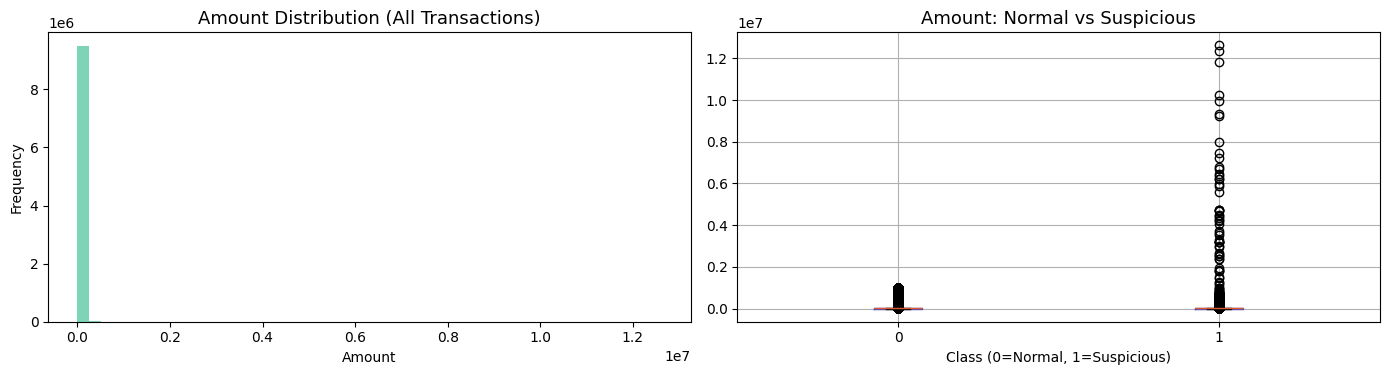

In [6]:
# Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Amount'], bins=50, color='#5DCAA5', edgecolor='none', alpha=0.8)
axes[0].set_title('Amount Distribution (All Transactions)', fontsize=13)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

df.boxplot(
    column='Amount',
    by=TARGET_COL,
    ax=axes[1],
    boxprops=dict(color='#534AB7'),
    medianprops=dict(color='#D85A30')
)

axes[1].set_title('Amount: Normal vs Suspicious', fontsize=13)
axes[1].set_xlabel('Class (0=Normal, 1=Suspicious)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing & Feature Engineering

> **[FIX 1 & 2]** Section subsampling dihapus sepenuhnya.  
> Dataset penuh (`df`) digunakan langsung. `resample()` tidak dipakai.  
> Imbalance ditangani secara internal oleh setiap model via `class_weight='balanced'` / `scale_pos_weight`.

In [7]:
# [FIX] Drop kolom yang berpotensi leakage sebelum feature engineering
# Leakage column tidak boleh masuk ke fitur karena terlalu dekat dengan jawaban target.

TARGET_COL = "Is_laundering"
leakage_cols = ["Laundering_type", "Type", "Is_Suspicious"]

if TARGET_COL not in df.columns:
    raise ValueError(f"Kolom target {TARGET_COL} tidak ditemukan. Cek nama kolom dataset.")

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].astype(int)

df_processed = df.copy()

existing_leakage = [c for c in leakage_cols if c in df_processed.columns]
if existing_leakage:
    df_processed.drop(columns=existing_leakage, inplace=True)
    print("🚫 Dropped leakage columns:", existing_leakage)
else:
    print("ℹ️ Tidak ada leakage column yang ditemukan.")

print("\nDistribusi target:")
print(df_processed[TARGET_COL].value_counts())

print("\nDistribusi target dalam persen:")
print(df_processed[TARGET_COL].value_counts(normalize=True) * 100)

print(f"\nAvailable columns ({df_processed.shape[1]}):")
for col in df_processed.columns:
    print(f"  - {col}: {df_processed[col].dtype}")


🚫 Dropped leakage columns: ['Laundering_type']

Distribusi target:
Is_laundering
0    9494979
1       9873
Name: count, dtype: int64

Distribusi target dalam persen:
Is_laundering
0    99.896127
1     0.103873
Name: proportion, dtype: float64

Available columns (11):
  - Time: object
  - Date: object
  - Sender_account: int64
  - Receiver_account: int64
  - Amount: float64
  - Payment_currency: object
  - Received_currency: object
  - Sender_bank_location: object
  - Receiver_bank_location: object
  - Payment_type: object
  - Is_laundering: int64


In [8]:
# ==========================================================
# FEATURE ENGINEERING BAGIAN 1: STATELESS AML FEATURES
# ==========================================================
# Stateless = tidak belajar dari distribusi seluruh dataset.
# Aman dilakukan sebelum split karena hanya memakai informasi pada baris transaksi itu sendiri.

# 1. Amount log transform
if "Amount" in df_processed.columns:
    df_processed["Amount"] = pd.to_numeric(df_processed["Amount"], errors="coerce")
    df_processed["Amount_log"] = np.log1p(df_processed["Amount"].clip(lower=0))
    print("✅ Amount_log dibuat dari Amount")

# 2. Currency risk / currency mismatch
if {"Payment_currency", "Received_currency"}.issubset(df_processed.columns):
    df_processed["CurrencyMismatch"] = (
        df_processed["Payment_currency"].astype(str) !=
        df_processed["Received_currency"].astype(str)
    ).astype(int)
    print("✅ CurrencyMismatch dibuat dari Payment_currency vs Received_currency")

# 3. Cross-border transaction
if {"Sender_bank_location", "Receiver_bank_location"}.issubset(df_processed.columns):
    df_processed["CrossBorder"] = (
        df_processed["Sender_bank_location"].astype(str) !=
        df_processed["Receiver_bank_location"].astype(str)
    ).astype(int)
    print("✅ CrossBorder dibuat dari Sender_bank_location vs Receiver_bank_location")

# 4. Time-derived behavioral features
# Target fitur yang dipakai paper: Hour, DayOfWeek, Month, IsWeekend.
# Jika Date berisi tanggal+jam, Hour bisa diambil dari Date.
# Jika Time tersedia terpisah, Hour diambil/diperbaiki dari Time.

if "Date" in df_processed.columns:
    date_parsed = pd.to_datetime(df_processed["Date"], errors="coerce")
    df_processed["DayOfWeek"] = date_parsed.dt.dayofweek.fillna(-1).astype(int)
    df_processed["Month"] = date_parsed.dt.month.fillna(-1).astype(int)
    df_processed["Day"] = date_parsed.dt.day.fillna(-1).astype(int)
    df_processed["IsWeekend"] = (df_processed["DayOfWeek"] >= 5).astype(int)

    # Jika Date juga punya komponen jam, ambil Hour sementara.
    if "Hour" not in df_processed.columns:
        df_processed["Hour"] = date_parsed.dt.hour.fillna(-1).astype(int)
    print("✅ DayOfWeek, Month, Day, IsWeekend dibuat dari Date")

if "Time" in df_processed.columns:
    # Format Time bisa HH:MM:SS atau string lain; parse secara aman.
    time_parsed = pd.to_datetime(df_processed["Time"].astype(str), errors="coerce")
    hour_from_time = time_parsed.dt.hour.fillna(-1).astype(int)

    # Time lebih spesifik untuk jam transaksi, jadi override Hour jika tersedia.
    df_processed["Hour"] = hour_from_time
    df_processed["Minute"] = time_parsed.dt.minute.fillna(-1).astype(int)
    print("✅ Hour dan Minute dibuat dari Time")

# Jika dataset tidak punya Date/Time, buat placeholder agar pipeline tetap jalan.
for col in ["Hour", "DayOfWeek", "Month", "IsWeekend"]:
    if col not in df_processed.columns:
        df_processed[col] = -1
        print(f"ℹ️ {col} tidak tersedia dari Date/Time, diisi -1")

# Kolom raw Date/Time dihapus setelah fiturnya dibuat.
drop_time_cols = [c for c in ["Date", "Time"] if c in df_processed.columns]
df_processed.drop(columns=drop_time_cols, inplace=True, errors="ignore")
print("Dropped raw time columns:", drop_time_cols)

# Account columns tidak dipakai sebagai ID mentah.
# Mereka akan dipakai setelah split untuk membuat fitur agregat anti-leakage.
ACCOUNT_COLS = [c for c in ["Sender_account", "Receiver_account"] if c in df_processed.columns]
print("\nAccount columns detected:", ACCOUNT_COLS)

print("\nShape setelah stateless feature engineering:", df_processed.shape)
print("AML engineered features yang dibuat:", [c for c in ["Amount_log", "CrossBorder", "CurrencyMismatch", "Hour", "DayOfWeek", "Month", "IsWeekend"] if c in df_processed.columns])

✅ Amount_log dibuat dari Amount
✅ CurrencyMismatch dibuat dari Payment_currency vs Received_currency
✅ CrossBorder dibuat dari Sender_bank_location vs Receiver_bank_location
✅ DayOfWeek, Month, Day, IsWeekend dibuat dari Date
✅ Hour dan Minute dibuat dari Time
Dropped raw time columns: ['Date', 'Time']

Account columns detected: ['Sender_account', 'Receiver_account']

Shape setelah stateless feature engineering: (9504852, 18)
AML engineered features yang dibuat: ['Amount_log', 'CrossBorder', 'CurrencyMismatch', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend']


In [9]:
# ==========================================================
# CEK CARDINALITY DAN SIAPKAN KOLOM KATEGORIKAL
# ==========================================================
# Sender_account dan Receiver_account tidak di-OneHot/Ordinal sebagai ID mentah.
# Keduanya akan diubah menjadi fitur agregat/frequency setelah split.

categorical_cols_all = df_processed.select_dtypes(include=["object", "category"]).columns.tolist()

print("Cardinality kolom kategorikal:")
for col in categorical_cols_all:
    print(f"  {col}: {df_processed[col].nunique():,} unique")

# Jangan encode account ID mentah
CAT_COLS_PRE = [
    c for c in categorical_cols_all
    if c != TARGET_COL and c not in ACCOUNT_COLS
]

print("\nKolom kategorikal awal yang akan dipertimbangkan untuk encoding:")
print(CAT_COLS_PRE)

print("\nCatatan:")
print("- Account ID tidak langsung jadi fitur mentah.")
print("- Account ID dipakai untuk membuat Sender/Receiver frequency dan amount statistics setelah split.")


Cardinality kolom kategorikal:
  Payment_currency: 13 unique
  Received_currency: 13 unique
  Sender_bank_location: 18 unique
  Receiver_bank_location: 18 unique
  Payment_type: 7 unique

Kolom kategorikal awal yang akan dipertimbangkan untuk encoding:
['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']

Catatan:
- Account ID tidak langsung jadi fitur mentah.
- Account ID dipakai untuk membuat Sender/Receiver frequency dan amount statistics setelah split.


### Catatan metodologi untuk paper

`Sender_account` dan `Receiver_account` tidak dimasukkan sebagai ID mentah karena cardinality tinggi dapat membuat model menghafal akun, bukan belajar pola AML. Notebook ini mengubahnya menjadi fitur perilaku akun seperti `Sender_freq`, `Receiver_freq`, `Sender_txn_count`, dan `Receiver_txn_count`. Statistik akun dihitung hanya dari train set, lalu diterapkan ke validation/test.

## 4. Split Data & Scaling (Anti Data Leakage)

> **[FIX 3 & 4]** `RandomOverSampler` dihapus.  
> `StandardScaler` sekarang di-**fit hanya pada data train**, lalu di-**transform saja** pada data test/val.  
> Split dilakukan menjadi **train / validation / test** (70 / 15 / 15) agar threshold tuning punya set tersendiri.

In [10]:
# === SPLIT FEATURES AND TARGET ===
# Pastikan semua leakage_cols di-drop
X_raw = df_processed.drop(
    columns=[TARGET_COL] + [c for c in leakage_cols if c in df_processed.columns],
    errors='ignore'
)
y = df_processed[TARGET_COL]

# Verifikasi tidak ada kolom leakage yang tersisa
leaked = [c for c in leakage_cols if c in X_raw.columns]
if leaked:
    print(f'❌ WARNING: kolom leakage masih ada di X: {leaked}')
else:
    print(f'✅ Verified: tidak ada kolom leakage di X_raw')

print(f'\nX_raw shape : {X_raw.shape}')
print(f'Target y    : {y.shape}  |  Suspicious: {y.sum():,} ({y.mean()*100:.3f}%)')

✅ Verified: tidak ada kolom leakage di X_raw

X_raw shape : (9504852, 17)
Target y    : (9504852,)  |  Suspicious: 9,873 (0.104%)


In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║ SPLIT → POST-SPLIT ACCOUNT FEATURES → ENCODING → SCALING ║
# ║ Semua yang 'belajar dari data' hanya dihitung dari TRAIN ║
# ╚══════════════════════════════════════════════════════════╝

# ── Step 1: Stratified split 70 / 15 / 15 ──────────────────
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

val_ratio = 0.15 / (1 - 0.15)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_ratio,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Copy agar tidak muncul SettingWithCopyWarning
X_train_raw = X_train_raw.copy()
X_val_raw = X_val_raw.copy()
X_test_raw = X_test_raw.copy()

print("✅ Split completed!")
print(f"  Train      : {X_train_raw.shape[0]:,} rows | positive: {y_train.sum():,}")
print(f"  Validation : {X_val_raw.shape[0]:,} rows | positive: {y_val.sum():,}")
print(f"  Test       : {X_test_raw.shape[0]:,} rows | positive: {y_test.sum():,}")

# ── Step 2: Account feature engineering dari TRAIN saja ─────
# Tujuan:
# - Tidak memakai Sender_account/Receiver_account sebagai ID mentah.
# - Tetap mengambil informasi perilaku akun: frequency/count, rata-rata amount, max amount.
# - Tidak leakage karena statistik hanya dihitung dari X_train.
# - Output utama: Sender_freq, Receiver_freq, Sender_txn_count, Receiver_txn_count.

def add_account_features(train_df, val_df, test_df, account_col, prefix):
    if account_col not in train_df.columns:
        print(f"ℹ️ {account_col} tidak ditemukan, skip.")
        return train_df, val_df, test_df, None

    if "Amount" not in train_df.columns:
        print(f"⚠️ Amount tidak ditemukan, hanya membuat frequency untuk {account_col}.")
        stats = train_df.groupby(account_col).size().reset_index(name=f"{prefix}_freq")
    else:
        stats = train_df.groupby(account_col)["Amount"].agg(
            **{
                f"{prefix}_freq": "count",
                f"{prefix}_txn_count": "count",
                f"{prefix}_amount_mean": "mean",
                f"{prefix}_amount_std": "std",
                f"{prefix}_amount_max": "max",
                f"{prefix}_amount_sum": "sum"
            }
        ).reset_index()

    global_amount_median = train_df["Amount"].median() if "Amount" in train_df.columns else 0

    def merge_stats(df_split):
        out = df_split.merge(stats, on=account_col, how="left")

        # Untuk akun baru di val/test yang tidak muncul di train
        for col in stats.columns:
            if col == account_col:
                continue
            if col.endswith("_std"):
                out[col] = out[col].fillna(0)
            elif col.endswith("_freq"):
                out[col] = out[col].fillna(0)
            elif "amount" in col:
                out[col] = out[col].fillna(global_amount_median)
            else:
                out[col] = out[col].fillna(0)

        if "Amount" in out.columns and f"{prefix}_amount_mean" in out.columns:
            out[f"Amount_vs_{prefix}_mean"] = out["Amount"] / (out[f"{prefix}_amount_mean"] + 1)

        # Drop raw account ID setelah statistik dibuat
        out.drop(columns=[account_col], inplace=True, errors="ignore")
        return out

    train_out = merge_stats(train_df)
    val_out = merge_stats(val_df)
    test_out = merge_stats(test_df)

    print(f"✅ Account features dibuat untuk {account_col} dengan prefix {prefix}")
    return train_out, val_out, test_out, stats

account_stats = {}

if "Sender_account" in X_train_raw.columns:
    X_train_raw, X_val_raw, X_test_raw, sender_stats = add_account_features(
        X_train_raw, X_val_raw, X_test_raw, "Sender_account", "Sender"
    )
    account_stats["Sender_account"] = sender_stats

if "Receiver_account" in X_train_raw.columns:
    X_train_raw, X_val_raw, X_test_raw, receiver_stats = add_account_features(
        X_train_raw, X_val_raw, X_test_raw, "Receiver_account", "Receiver"
    )
    account_stats["Receiver_account"] = receiver_stats

joblib.dump(account_stats, "aml_account_stats.pkl")
print("✅ Account stats disimpan ke aml_account_stats.pkl")

# ── Step 3: Numeric imputation dari TRAIN saja ───────────────
num_cols = X_train_raw.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
num_medians = X_train_raw[num_cols].median(numeric_only=True)

X_train_raw[num_cols] = X_train_raw[num_cols].fillna(num_medians)
X_val_raw[num_cols] = X_val_raw[num_cols].fillna(num_medians)
X_test_raw[num_cols] = X_test_raw[num_cols].fillna(num_medians)

joblib.dump(num_medians, "aml_numeric_medians.pkl")
print("✅ Numeric missing value diisi dengan median dari train")

# ── Step 4: Categorical encoding fit HANYA pada TRAIN ─────────
CAT_COLS = [
    c for c in X_train_raw.select_dtypes(include=["object", "category"]).columns
]

for col in CAT_COLS:
    X_train_raw[col] = X_train_raw[col].astype(str).fillna("UNKNOWN")
    X_val_raw[col] = X_val_raw[col].astype(str).fillna("UNKNOWN")
    X_test_raw[col] = X_test_raw[col].astype(str).fillna("UNKNOWN")

if CAT_COLS:
    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        dtype=np.float32
    )

    X_train_raw[CAT_COLS] = encoder.fit_transform(X_train_raw[CAT_COLS])
    X_val_raw[CAT_COLS] = encoder.transform(X_val_raw[CAT_COLS])
    X_test_raw[CAT_COLS] = encoder.transform(X_test_raw[CAT_COLS])

    joblib.dump(encoder, "aml_encoder.pkl")
    joblib.dump(CAT_COLS, "aml_cat_cols.pkl")

    print("✅ OrdinalEncoder fit pada train saja")
    print("Encoded columns:", CAT_COLS)
else:
    encoder = None
    print("ℹ️ Tidak ada kolom kategorikal untuk di-encode.")

# ── Step 5: Align columns ────────────────────────────────────
feat_cols = X_train_raw.columns.tolist()
X_val_raw = X_val_raw.reindex(columns=feat_cols, fill_value=0)
X_test_raw = X_test_raw.reindex(columns=feat_cols, fill_value=0)

joblib.dump(feat_cols, "aml_feature_columns.pkl")

# ── Step 6: Scaling fit HANYA pada TRAIN ─────────────────────
# Tree model sebenarnya tidak wajib scaling, tetapi dipertahankan agar konsisten dengan notebook lama.
# Cast ke float32 agar lebih hemat RAM.

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw).astype(np.float32),
    columns=feat_cols
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_raw).astype(np.float32),
    columns=feat_cols
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw).astype(np.float32),
    columns=feat_cols
)

joblib.dump(scaler, "aml_scaler.pkl")

# Reset index y agar aman untuk SHAP/sample alignment
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("\n✅ Preprocessing selesai")
print("Final feature count:", X_train_scaled.shape[1])
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

print("\nFinal features:")
print(feat_cols)

gc.collect()


✅ Split completed!
  Train      : 6,653,396 rows | positive: 6,911
  Validation : 1,425,728 rows | positive: 1,481
  Test       : 1,425,728 rows | positive: 1,481
✅ Account features dibuat untuk Sender_account dengan prefix Sender
✅ Account features dibuat untuk Receiver_account dengan prefix Receiver
✅ Account stats disimpan ke aml_account_stats.pkl
✅ Numeric missing value diisi dengan median dari train
✅ OrdinalEncoder fit pada train saja
Encoded columns: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']

✅ Preprocessing selesai
Final feature count: 29
Train: (6653396, 29)
Validation: (1425728, 29)
Test: (1425728, 29)

Final features:
['Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Amount_log', 'CurrencyMismatch', 'CrossBorder', 'DayOfWeek', 'Month', 'Day', 'IsWeekend', 'Hour', 'Minute', 'Sender_freq', 'Sender_txn_count', 'Sender_amount_mean', 'Sender_amoun

3903

## 5. Training Model

> **[FIX 3 & 5]** Tidak ada `RandomOverSampler`.  
> Setiap model menggunakan `class_weight='balanced'` / `scale_pos_weight` secara internal.  
> Fungsi `evaluate_model` sekarang mencari **threshold optimal dari validation set** berdasarkan F1-Score,  
> lalu menerapkan threshold tersebut untuk confusion matrix pada test set.

In [12]:
def find_optimal_threshold(y_true_val, y_proba_val, beta=2.0):
    '''
    Cari threshold optimal dari validation set menggunakan F-beta Score.
    beta=2 memberi bobot lebih besar pada recall, cocok untuk AML.
    '''
    precisions, recalls, thresholds = precision_recall_curve(y_true_val, y_proba_val)

    best_thresh = 0.5
    best_fbeta = 0.0
    best_p = 0.0
    best_r = 0.0

    for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
        if p + r == 0:
            continue
        fb = (1 + beta**2) * (p * r) / ((beta**2 * p) + r)
        if fb > best_fbeta:
            best_fbeta = fb
            best_thresh = t
            best_p = p
            best_r = r

    return best_thresh, best_fbeta, best_p, best_r


def evaluate_model(name, model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    '''
    Train -> threshold tuning dari validation set -> evaluasi test set.
    Menghasilkan metrik klasifikasi dan performa inferensi.
    '''
    print("\n" + "=" * 70)
    print(f"Training {name}")
    print("=" * 70)

    if psutil is not None:
        process = psutil.Process(os.getpid())
        mem_before_train = process.memory_info().rss / (1024 ** 2)
    else:
        mem_before_train = np.nan

    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    if psutil is not None:
        mem_after_train = process.memory_info().rss / (1024 ** 2)
        train_mem_delta = mem_after_train - mem_before_train
    else:
        train_mem_delta = np.nan

    # Threshold tuning dari validation set
    y_proba_val = model.predict_proba(X_val)[:, 1]
    best_thresh, val_fb, val_p, val_r = find_optimal_threshold(y_val, y_proba_val, beta=2.0)

    # Inference test set
    if psutil is not None:
        mem_before_infer = process.memory_info().rss / (1024 ** 2)
    else:
        mem_before_infer = np.nan

    t1 = time.perf_counter()
    y_proba_te = model.predict_proba(X_te)[:, 1]
    inference_time = time.perf_counter() - t1

    if psutil is not None:
        mem_after_infer = process.memory_info().rss / (1024 ** 2)
        infer_mem_delta = mem_after_infer - mem_before_infer
    else:
        infer_mem_delta = np.nan

    y_pred_te = (y_proba_te >= best_thresh).astype(int)

    f1 = f1_score(y_te, y_pred_te, zero_division=0)
    precision = precision_score(y_te, y_pred_te, zero_division=0)
    recall = recall_score(y_te, y_pred_te, zero_division=0)
    pr_auc = average_precision_score(y_te, y_proba_te)
    roc = roc_auc_score(y_te, y_proba_te)
    cm = confusion_matrix(y_te, y_pred_te)

    latency_per_sample_ms = (inference_time / len(X_te)) * 1000
    throughput = len(X_te) / inference_time

    # Simpan sementara untuk ukur model size
    model_path = f"tmp_{name.replace(' ', '_')}.pkl"
    joblib.dump(model, model_path)
    model_size_mb = os.path.getsize(model_path) / (1024 ** 2)

    print(f"Optimal threshold (F2 from val): {best_thresh:.4f}")
    print(f"Val Precision: {val_p:.4f} | Val Recall: {val_r:.4f} | Val F2: {val_fb:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall   : {recall:.4f}")
    print(f"Test F1       : {f1:.4f}")
    print(f"Test PR-AUC   : {pr_auc:.4f}")
    print(f"Test ROC-AUC  : {roc:.4f}")
    print(f"Train time    : {train_time:.2f} seconds")
    print(f"Infer time    : {inference_time:.4f} seconds")
    print(f"Latency       : {latency_per_sample_ms:.6f} ms/sample")
    print(f"Throughput    : {throughput:,.2f} rows/second")
    print(f"Train mem Δ   : {train_mem_delta:.2f} MB")
    print(f"Infer mem Δ   : {infer_mem_delta:.2f} MB")
    print(f"Model size    : {model_size_mb:.3f} MB")

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred_te, target_names=["Normal", "Suspicious"], zero_division=0))

    print("\nConfusion Matrix:")
    print(cm)

    scores = {
        "name": name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc,
        "threshold": float(best_thresh),
        "train_time_s": train_time,
        "inference_time_s": inference_time,
        "latency_ms_per_sample": latency_per_sample_ms,
        "throughput_rows_s": throughput,
        "train_memory_delta_mb": train_mem_delta,
        "infer_memory_delta_mb": infer_mem_delta,
        "model_size_mb": model_size_mb
    }

    gc.collect()

    return model, y_pred_te, y_proba_te, scores


In [13]:
# === MODEL 1: Random Forest RAM-Friendly ===
# Random Forest sangat boros RAM untuk 9,5 juta baris.
# max_samples dipakai agar baseline RF tetap bisa jalan di cloud/laptop.
# Catatan paper: ini adalah RAM-friendly Random Forest baseline.

print("Training Random Forest...")

rf_model, rf_pred, rf_proba, rf_scores = evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=30,
        max_depth=10,
        max_samples=0.2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=2
    ),
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test
)


Training Random Forest...

Training Random Forest
Optimal threshold (F2 from val): 0.8556
Val Precision: 0.4562 | Val Recall: 0.6158 | Val F2: 0.5755
Test Precision: 0.4598
Test Recall   : 0.6293
Test F1       : 0.5314
Test PR-AUC   : 0.5985
Test ROC-AUC  : 0.9924
Train time    : 87.23 seconds
Infer time    : 1.1150 seconds
Latency       : 0.000782 ms/sample
Throughput    : 1,278,712.73 rows/second
Train mem Δ   : -409.27 MB
Infer mem Δ   : 179.55 MB
Model size    : 1.030 MB

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1424247
  Suspicious       0.46      0.63      0.53      1481

    accuracy                           1.00   1425728
   macro avg       0.73      0.81      0.77   1425728
weighted avg       1.00      1.00      1.00   1425728


Confusion Matrix:
[[1423152    1095]
 [    549     932]]


In [14]:
# === MODEL 2: XGBoost ===
# Imbalance ditangani dengan scale_pos_weight.
# subsample dan colsample_bytree dibuat 1.0 agar tidak ada row/feature subsampling eksplisit.

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pw = neg_count / pos_count

print(f"scale_pos_weight: {scale_pw:.2f}")

print("Training XGBoost...")

xgb_model, xgb_pred, xgb_proba, xgb_scores = evaluate_model(
    "XGBoost",
    XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=3,
        gamma=0.1,
        scale_pos_weight=scale_pw,
        subsample=1.0,
        colsample_bytree=1.0,
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbosity=0
    ),
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test
)


scale_pos_weight: 961.73
Training XGBoost...

Training XGBoost
Optimal threshold (F2 from val): 0.9700
Val Precision: 0.7881 | Val Recall: 0.8238 | Val F2: 0.8164
Test Precision: 0.7843
Test Recall   : 0.8251
Test F1       : 0.8042
Test PR-AUC   : 0.8608
Test ROC-AUC  : 0.9970
Train time    : 78.32 seconds
Infer time    : 1.5406 seconds
Latency       : 0.001081 ms/sample
Throughput    : 925,425.55 rows/second
Train mem Δ   : 6.20 MB
Infer mem Δ   : 10.92 MB
Model size    : 0.824 MB

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1424247
  Suspicious       0.78      0.83      0.80      1481

    accuracy                           1.00   1425728
   macro avg       0.89      0.91      0.90   1425728
weighted avg       1.00      1.00      1.00   1425728


Confusion Matrix:
[[1423911     336]
 [    259    1222]]


In [15]:
# === MODEL 3: LightGBM ===
# Imbalance ditangani dengan class_weight='balanced'.
# LightGBM biasanya paling kuat untuk dataset tabular AML besar.

print("Training LightGBM...")

lgbm_model, lgbm_pred, lgbm_proba, lgbm_scores = evaluate_model(
    "LightGBM",
    LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbose=-1
    ),
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test
)


Training LightGBM...

Training LightGBM
Optimal threshold (F2 from val): 0.9771
Val Precision: 0.8232 | Val Recall: 0.8238 | Val F2: 0.8237
Test Precision: 0.8244
Test Recall   : 0.8211
Test F1       : 0.8227
Test PR-AUC   : 0.8666
Test ROC-AUC  : 0.9976
Train time    : 77.40 seconds
Infer time    : 6.1703 seconds
Latency       : 0.004328 ms/sample
Throughput    : 231,061.44 rows/second
Train mem Δ   : -34.98 MB
Infer mem Δ   : 21.76 MB
Model size    : 0.696 MB

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1424247
  Suspicious       0.82      0.82      0.82      1481

    accuracy                           1.00   1425728
   macro avg       0.91      0.91      0.91   1425728
weighted avg       1.00      1.00      1.00   1425728


Confusion Matrix:
[[1423988     259]
 [    265    1216]]


## 6. Visualisasi & Evaluasi

In [16]:
# Comparison of all models
results = [rf_scores, xgb_scores, lgbm_scores]
results_df = pd.DataFrame(results).sort_values(by="pr_auc", ascending=False)

print("=== Model Comparison ===")
display(results_df)

results_df.to_csv("aml_model_comparison_results.csv", index=False)
print("Saved: aml_model_comparison_results.csv")


=== Model Comparison ===


,name,precision,recall,f1,pr_auc,roc_auc,threshold,train_time_s,inference_time_s,latency_ms_per_sample,throughput_rows_s,train_memory_delta_mb,infer_memory_delta_mb,model_size_mb
2,LightGBM,0.824407,0.821067,0.822733,0.866619,0.997562,0.977055,77.404351,6.170341,0.004328,2.310614e+05,-34.984375,21.757812,0.695667
1,XGBoost,0.784339,0.825118,0.804212,0.860840,0.997050,0.969962,78.319663,1.540619,0.001081,9.254255e+05,6.199219,10.917969,0.823647
0,Random Forest,0.459793,0.629305,0.531357,0.598545,0.992400,0.855622,87.233654,1.114971,0.000782,1.278713e+06,-409.265625,179.554688,1.029778


Saved: aml_model_comparison_results.csv


## 6.1 Evaluasi Threshold Manual 0.5–0.9

In [17]:
# ==========================================================
# THRESHOLD EVALUATION TABLE
# ==========================================================
# AML biasanya lebih memprioritaskan Recall tinggi.
# Tabel ini membantu melihat trade-off Precision/Recall/F1 pada beberapa threshold.

def threshold_report(y_true, y_proba, thresholds=(0.5, 0.6, 0.7, 0.8, 0.9)):
    rows = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
            "predicted_suspicious": int(pred.sum())
        })
    return pd.DataFrame(rows)

print("=== Threshold Report — Random Forest ===")
rf_threshold_table = threshold_report(y_test, rf_proba)
display(rf_threshold_table)

print("=== Threshold Report — XGBoost ===")
xgb_threshold_table = threshold_report(y_test, xgb_proba)
display(xgb_threshold_table)

print("=== Threshold Report — LightGBM ===")
lgbm_threshold_table = threshold_report(y_test, lgbm_proba)
display(lgbm_threshold_table)

# Simpan tabel threshold untuk lampiran paper
rf_threshold_table.assign(model="Random Forest").to_csv("threshold_report_random_forest.csv", index=False)
xgb_threshold_table.assign(model="XGBoost").to_csv("threshold_report_xgboost.csv", index=False)
lgbm_threshold_table.assign(model="LightGBM").to_csv("threshold_report_lightgbm.csv", index=False)

threshold_all = pd.concat([
    rf_threshold_table.assign(model="Random Forest"),
    xgb_threshold_table.assign(model="XGBoost"),
    lgbm_threshold_table.assign(model="LightGBM")
], ignore_index=True)
threshold_all.to_csv("threshold_report_all_models.csv", index=False)
print("Saved: threshold_report_all_models.csv")

=== Threshold Report — Random Forest ===


,threshold,precision,recall,f1,f2,predicted_suspicious
0,0.5,0.050560,0.883187,0.095645,0.205699,25870
1,0.6,0.080966,0.850777,0.147861,0.293214,15562
2,0.7,0.142737,0.801485,0.242319,0.416784,8316
3,0.8,0.287483,0.705604,0.408522,0.546605,3635
4,0.9,0.666084,0.514517,0.580571,0.539049,1144


=== Threshold Report — XGBoost ===


,threshold,precision,recall,f1,f2,predicted_suspicious
0,0.5,0.080320,0.949359,0.148109,0.300055,17505
1,0.6,0.104755,0.937205,0.188446,0.361948,13250
2,0.7,0.142961,0.929102,0.247794,0.442472,9625
3,0.8,0.217343,0.915598,0.351295,0.557428,6239
4,0.9,0.392239,0.887238,0.543987,0.708432,3350


=== Threshold Report — LightGBM ===


,threshold,precision,recall,f1,f2,predicted_suspicious
0,0.5,0.072695,0.955436,0.135109,0.278664,19465
1,0.6,0.091864,0.944632,0.167445,0.330686,15229
2,0.7,0.120128,0.934504,0.212890,0.396675,11521
3,0.8,0.170433,0.921675,0.287671,0.489844,8009
4,0.9,0.299933,0.901418,0.450101,0.643373,4451


Saved: threshold_report_all_models.csv


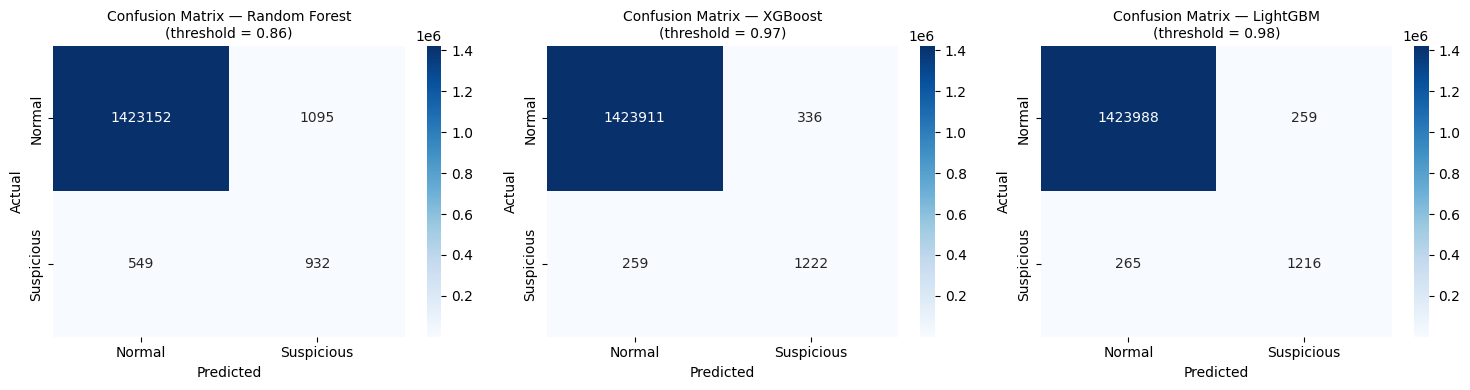

In [18]:
# [FIX 5] Confusion Matrix menggunakan threshold yang sudah di-tuning (bukan 0.5)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    ('Random Forest', rf_pred,   rf_scores['threshold']),
    ('XGBoost',       xgb_pred,  xgb_scores['threshold']),
    ('LightGBM',      lgbm_pred, lgbm_scores['threshold']),
]

for ax, (name, pred, thresh) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Suspicious'],
                yticklabels=['Normal', 'Suspicious'])
    ax.set_title(f'Confusion Matrix — {name}\n(threshold = {thresh:.2f})', fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

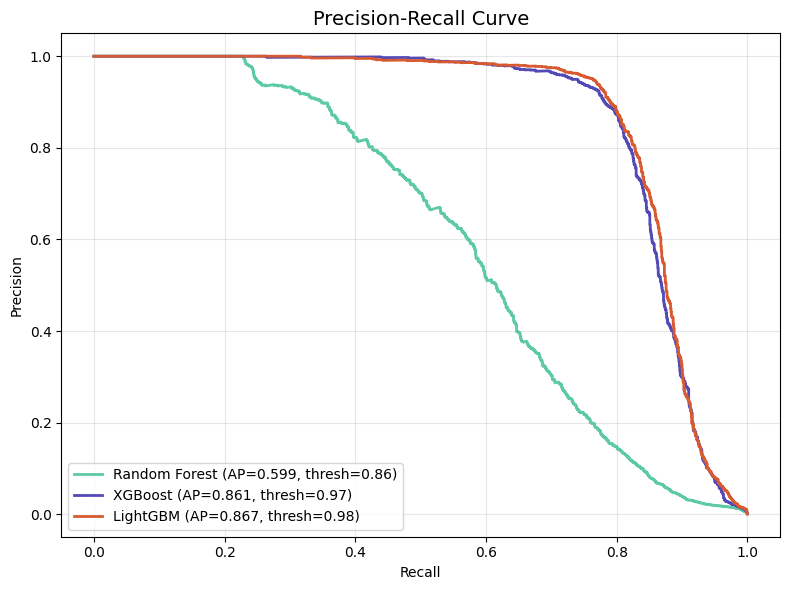

In [19]:
# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, thresh, color in [
    ('Random Forest', rf_proba,   rf_scores['threshold'],   '#5DCAA5'),
    ('XGBoost',       xgb_proba,  xgb_scores['threshold'],  '#534AB7'),
    ('LightGBM',      lgbm_proba, lgbm_scores['threshold'], '#D85A30')
]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f'{name} (AP={ap:.3f}, thresh={thresh:.2f})', color=color, linewidth=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

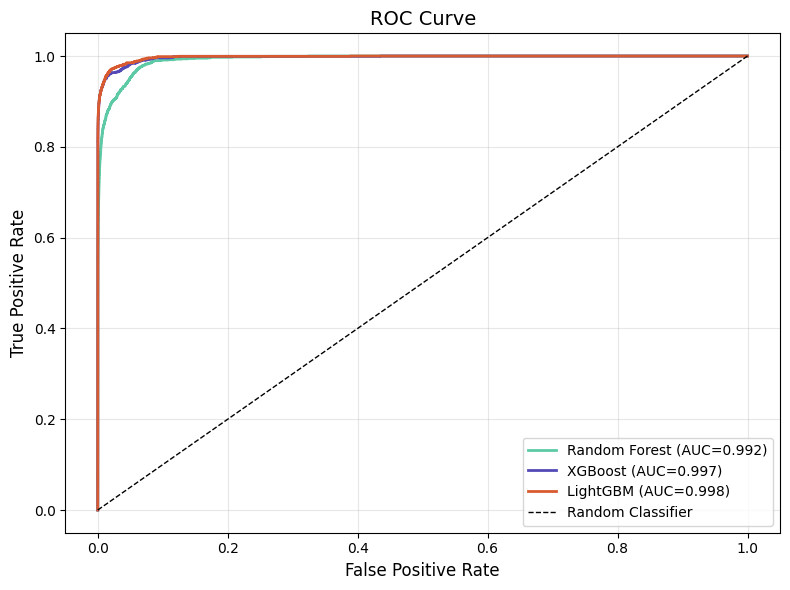

In [20]:
# ROC Curve
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Random Forest', rf_proba,   '#5DCAA5'),
    ('XGBoost',       xgb_proba,  '#534AB7'),
    ('LightGBM',      lgbm_proba, '#D85A30')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

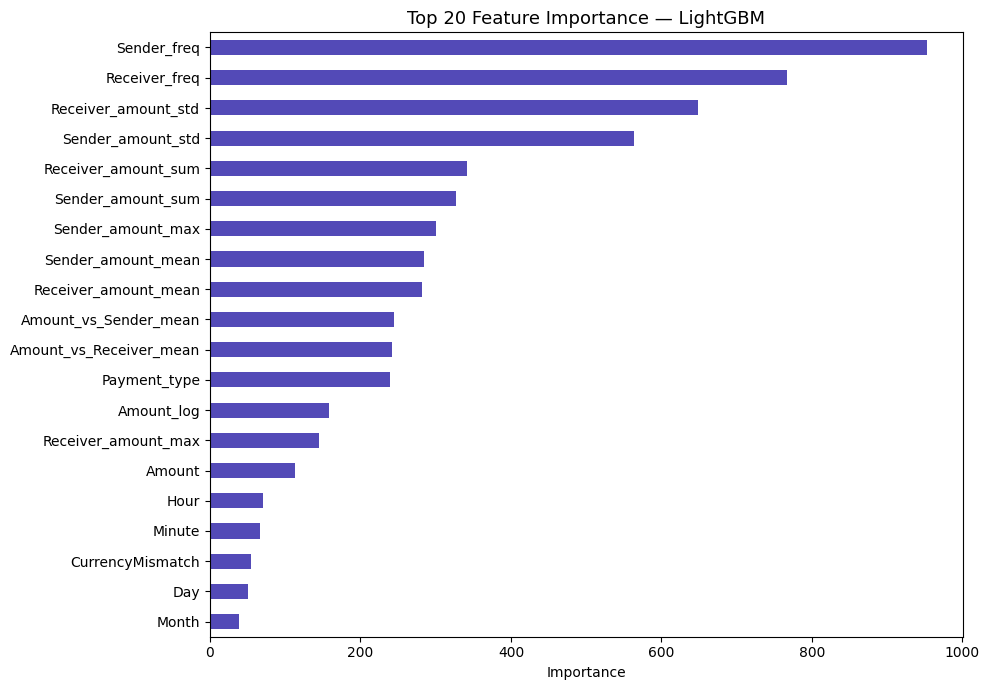

In [21]:
# Feature Importance dari model terbaik berdasarkan PR-AUC
best_name = results_df.iloc[0]["name"]
model_map = {"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgbm_model}
best_for_fi = model_map[best_name]

if hasattr(best_for_fi, "feature_importances_"):
    fi = pd.Series(best_for_fi.feature_importances_, index=X_train_scaled.columns)
    fi_top20 = fi.nlargest(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    fi_top20.sort_values().plot.barh(ax=ax, color="#534AB7", edgecolor="none")
    ax.set_title(f"Top 20 Feature Importance — {best_name}", fontsize=13)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance_best_model.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Model {best_name} tidak memiliki feature_importances_.")


## 7. XAI — Explainable AI dengan SHAP

SHAP (SHapley Additive exPlanations) digunakan untuk menjelaskan **mengapa** model memprediksi suatu transaksi sebagai mencurigakan.

In [22]:
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])

0

In [23]:
import shap
shap.initjs()

# Reset index agar label dan sample aman
X_test_scaled_reset = X_test_scaled.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

X_shap = X_test_scaled_reset.sample(n=min(2000, len(X_test_scaled_reset)), random_state=RANDOM_STATE)

print("Calculating SHAP values using TreeExplainer for LightGBM...")
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_shap)

print("SHAP calculation completed.")


Calculating SHAP values using TreeExplainer for LightGBM...
SHAP calculation completed.


=== SHAP Summary Plot ===


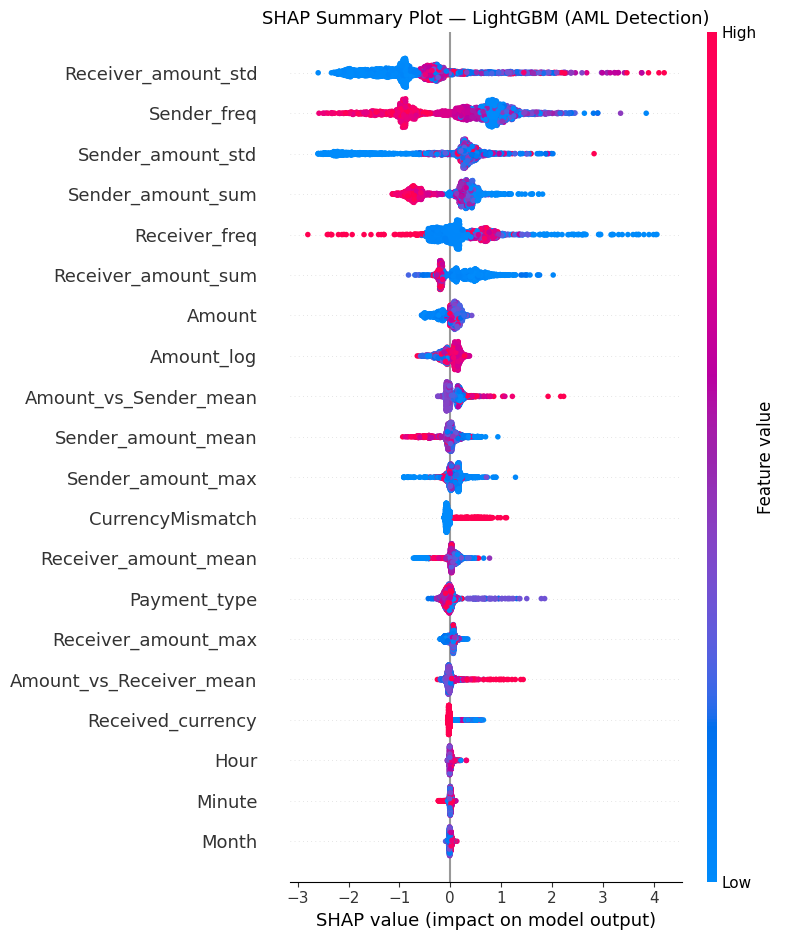

In [24]:
# SHAP Summary Plot (Beeswarm)
print("=== SHAP Summary Plot ===")
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Plot — LightGBM (AML Detection)", fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

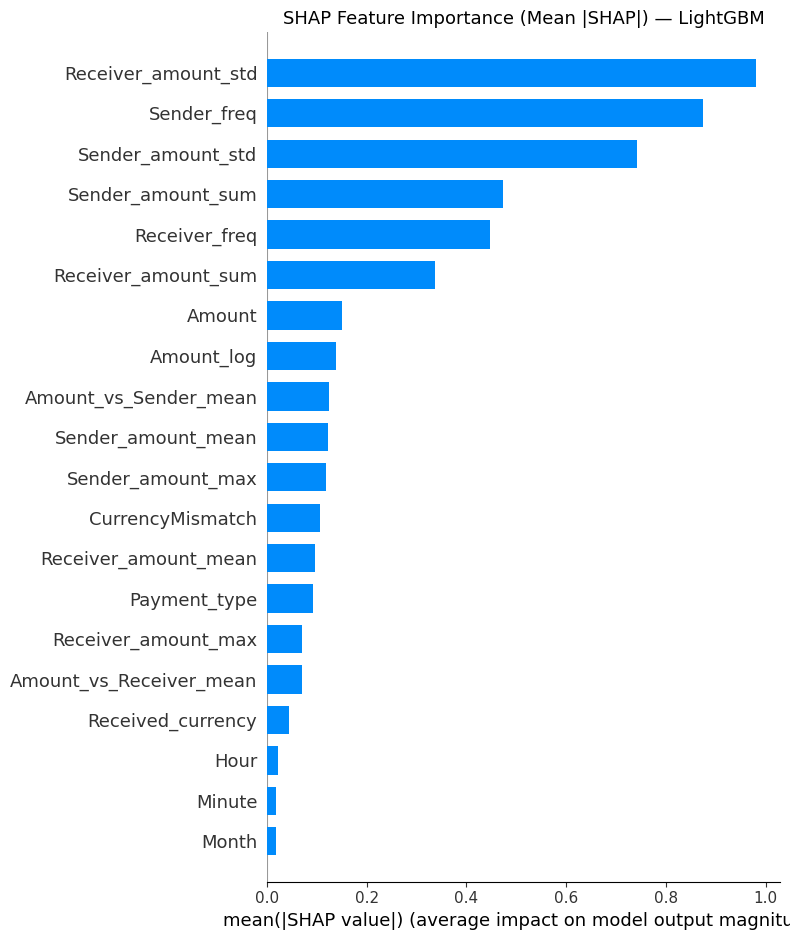

In [25]:
# SHAP Bar Plot
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — LightGBM", fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining suspicious transaction (index: 35032)


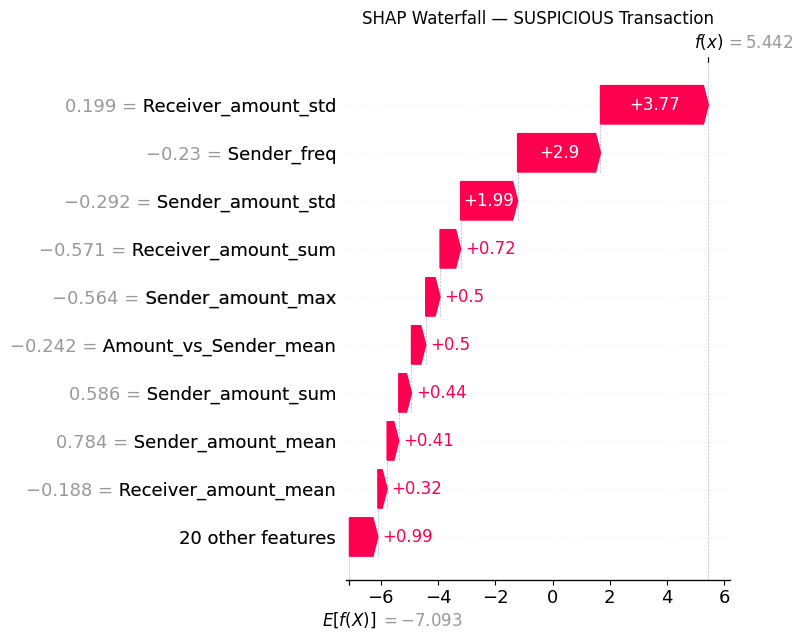

In [26]:
# SHAP Waterfall — 1 Suspicious Transaction
y_shap = y_test_reset.loc[X_shap.index]
suspicious_idx = y_shap[y_shap == 1].index

if len(suspicious_idx) > 0:
    idx_in_shap = X_shap.index.get_loc(suspicious_idx[0])
    print(f"Explaining suspicious transaction (index: {suspicious_idx[0]})")
    shap.waterfall_plot(shap_values[idx_in_shap], show=False)
    plt.title("SHAP Waterfall — SUSPICIOUS Transaction", fontsize=12)
    plt.tight_layout()
    plt.savefig("shap_waterfall_suspicious.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Tidak ada suspicious sample di X_shap.")


Explaining normal transaction (index: 108375)


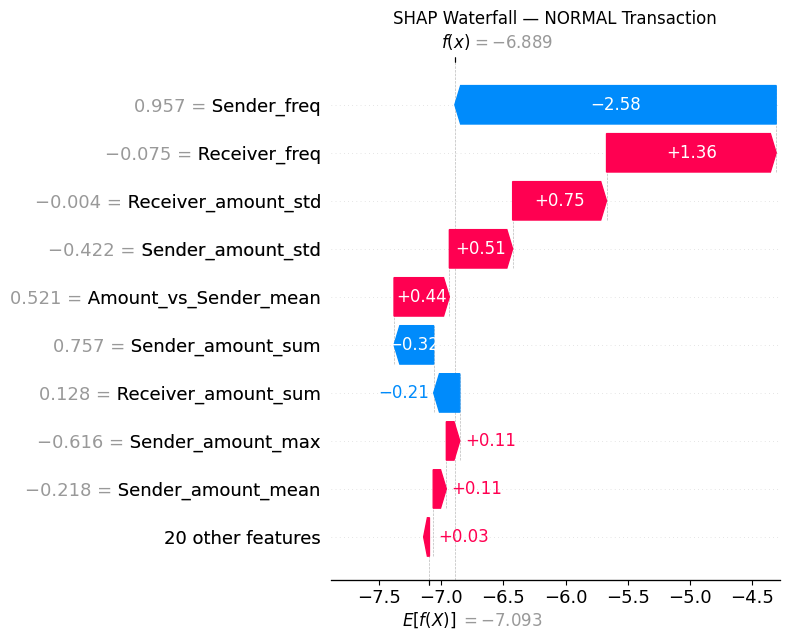

In [27]:
# SHAP Waterfall — 1 Normal Transaction
y_shap = y_test_reset.loc[X_shap.index]
normal_idx = y_shap[y_shap == 0].index

if len(normal_idx) > 0:
    idx_in_shap = X_shap.index.get_loc(normal_idx[0])
    print(f"Explaining normal transaction (index: {normal_idx[0]})")
    shap.waterfall_plot(shap_values[idx_in_shap], show=False)
    plt.title("SHAP Waterfall — NORMAL Transaction", fontsize=12)
    plt.tight_layout()
    plt.savefig("shap_waterfall_normal.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Tidak ada normal sample di X_shap.")


Dependence plot for the most important feature: Receiver_freq


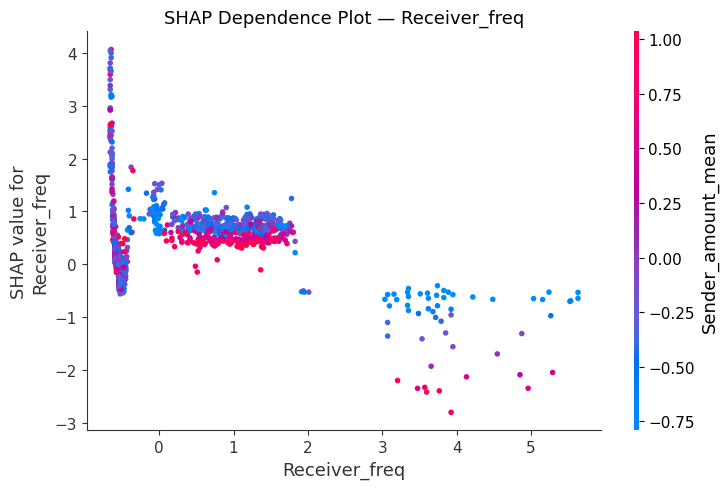


✅ All SHAP plots completed!


In [28]:
# SHAP Dependence Plot — Most Important Feature
top_feature = X_shap.columns[shap_values.values[:, :].mean(axis=0).argsort()[::-1][0]]
print(f"Dependence plot for the most important feature: {top_feature}")

shap.dependence_plot(top_feature, shap_values.values, X_shap, show=False)
plt.title(f"SHAP Dependence Plot — {top_feature}", fontsize=13)
plt.tight_layout()
plt.savefig('shap_dependence_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All SHAP plots completed!")

## 8. Simpan Model Terbaik

In [29]:
# Select model dengan PR-AUC tertinggi
best = max([rf_scores, xgb_scores, lgbm_scores], key=lambda x: x["pr_auc"])
model_map = {"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgbm_model}
best_model = model_map[best["name"]]

print(f"Best model   : {best['name']}")
print(f"Best PR-AUC  : {best['pr_auc']:.4f}")
print(f"Best ROC-AUC : {best['roc_auc']:.4f}")
print(f"Threshold    : {best['threshold']:.4f}")

joblib.dump(best_model, "aml_best_model.pkl")
joblib.dump(best["threshold"], "aml_threshold.pkl")
joblib.dump(best, "aml_best_scores.pkl")

print("\nSaved artifacts:")
print("- aml_best_model.pkl")
print("- aml_threshold.pkl")
print("- aml_best_scores.pkl")
print("- aml_scaler.pkl")
print("- aml_encoder.pkl")
print("- aml_account_stats.pkl")
print("- aml_feature_columns.pkl")


Best model   : LightGBM
Best PR-AUC  : 0.8666
Best ROC-AUC : 0.9976
Threshold    : 0.9771

Saved artifacts:
- aml_best_model.pkl
- aml_threshold.pkl
- aml_best_scores.pkl
- aml_scaler.pkl
- aml_encoder.pkl
- aml_account_stats.pkl
- aml_feature_columns.pkl


## 9. Contoh Prediksi Transaksi Baru

In [30]:
# Load artifacts untuk inference
optimal_threshold = joblib.load("aml_threshold.pkl")
scaler_loaded = joblib.load("aml_scaler.pkl")
feature_cols_loaded = joblib.load("aml_feature_columns.pkl")
num_medians_loaded = joblib.load("aml_numeric_medians.pkl")
account_stats_loaded = joblib.load("aml_account_stats.pkl")
enc_loaded = joblib.load("aml_encoder.pkl") if os.path.exists("aml_encoder.pkl") else None
cat_cols_loaded = joblib.load("aml_cat_cols.pkl") if os.path.exists("aml_cat_cols.pkl") else []

def predict_processed_transaction(processed_row_df, threshold=optimal_threshold):
    '''
    Demo inference dari baris yang sudah melewati preprocessing seperti X_test_raw.
    Untuk deployment asli, pastikan proses feature engineering awal sama seperti notebook ini.
    '''
    row = processed_row_df.copy()
    row = row.reindex(columns=feature_cols_loaded, fill_value=0)

    # numeric missing
    for col in num_medians_loaded.index:
        if col in row.columns:
            row[col] = pd.to_numeric(row[col], errors="coerce").fillna(num_medians_loaded[col])

    # categorical encoding jika masih ada cat cols
    if enc_loaded is not None and cat_cols_loaded:
        cols_present = [c for c in cat_cols_loaded if c in row.columns]
        if cols_present:
            row[cols_present] = enc_loaded.transform(row[cols_present].astype(str).fillna("UNKNOWN"))

    row_scaled = scaler_loaded.transform(row).astype(np.float32)

    proba = best_model.predict_proba(row_scaled)[0][1]
    pred = int(proba >= threshold)

    print(f"Prediction      : {'⚠️ SUSPICIOUS' if pred == 1 else '✅ NORMAL'}")
    print(f"Suspicious prob : {proba:.4f} ({proba*100:.2f}%)")
    print(f"Threshold (F2)  : {threshold:.4f}")
    return pred, proba

# Demo: ambil 1 baris dari X_test_raw yang sudah diproses
sample_df = X_test_raw.iloc[[0]].copy()
print(f"Actual label : {y_test.iloc[0]} ({'Suspicious' if y_test.iloc[0] == 1 else 'Normal'})")
predict_processed_transaction(sample_df)


Actual label : 0 (Normal)
Prediction      : ✅ NORMAL
Suspicious prob : 0.0030 (0.30%)
Threshold (F2)  : 0.9771


(0, np.float64(0.003005097299377523))

## 10. Inference Benchmark & Computational Performance

Mengukur efisiensi komputasi model terbaik untuk menilai kelayakan **Edge AI deployment**.

In [31]:
import sys, os, time, json, threading, warnings, gc
import numpy as np
import psutil

warnings.filterwarnings('ignore')

N_LOGICAL_CORES = psutil.cpu_count(logical=True) or 1
print(f'✅ Library siap | Logical cores terdeteksi: {N_LOGICAL_CORES}')

✅ Library siap | Logical cores terdeteksi: 8


In [32]:
class ResourceMonitor:
    def __init__(self, interval=0.1):
        self.interval    = interval
        self.cpu_raw     = []
        self.mem_samples = []
        self._running    = False
        self._thread     = None
        self._proc       = psutil.Process(os.getpid())
        self._proc.cpu_percent(interval=None)
        time.sleep(0.2)
        self._proc.cpu_percent(interval=None)

    def start(self):
        self._running = True
        self._thread  = threading.Thread(target=self._poll, daemon=True)
        self._thread.start()

    def stop(self):
        self._running = False
        if self._thread:
            self._thread.join(timeout=5)

    def _poll(self):
        while self._running:
            self.cpu_raw.append(self._proc.cpu_percent(interval=None))
            self.mem_samples.append(self._proc.memory_info().rss / (1024**2))
            time.sleep(self.interval)

    @property
    def avg_cpu_per_core(self):
        valid = [x for x in self.cpu_raw if x > 0]
        if not valid:
            return 0.0
        return round((sum(valid) / len(valid)) / N_LOGICAL_CORES, 2)

    @property
    def avg_cpu_total(self):
        valid = [x for x in self.cpu_raw if x > 0]
        return round(sum(valid) / len(valid), 2) if valid else 0.0

    @property
    def peak_mem_mb(self):
        return round(max(self.mem_samples), 2) if self.mem_samples else 0.0

    @property
    def n_valid(self):
        return len([x for x in self.cpu_raw if x > 0])


def make_data(n):
    rng = np.random.default_rng(seed=42)
    return np.column_stack([
        rng.integers(1000,9999,size=n), rng.integers(1000,9999,size=n),
        rng.exponential(5000,size=n),   rng.integers(0,10,size=n),
        rng.integers(0,10,size=n),      rng.integers(0,50,size=n),
        rng.integers(0,50,size=n),      rng.integers(0,5,size=n),
        rng.integers(0,24,size=n),      rng.integers(0,7,size=n),
        rng.integers(1,13,size=n),      rng.integers(0,2,size=n),
        rng.integers(0,24,size=n),      rng.integers(0,7,size=n),
        rng.integers(1,13,size=n),      rng.integers(0,2,size=n),
        rng.integers(0,2,size=n),       rng.integers(1,200,size=n),
        rng.exponential(4000,size=n),   rng.exponential(1500,size=n),
        rng.exponential(20000,size=n),  rng.normal(1.0,0.5,size=n),
    ]).astype(np.float64)


print(f'✅ ResourceMonitor & make_data terdefinisi | Logical cores: {N_LOGICAL_CORES}')

✅ ResourceMonitor & make_data terdefinisi | Logical cores: 8


In [33]:
# 10.1  MODEL SIZE + MEMORY FOOTPRINT
MODEL_PATH   = 'aml_best_model.pkl'
SCALER_PATH  = 'aml_scaler.pkl'
THRESH_PATH  = 'aml_threshold.pkl'

model_size_mb  = os.path.getsize(MODEL_PATH)  / (1024**2)
scaler_size_mb = os.path.getsize(SCALER_PATH) / (1024**2)

print('━'*55)
print('  MODEL SIZE ON DISK')
print('━'*55)
print(f'  aml_best_model.pkl : {model_size_mb:.3f} MB')
print(f'  aml_scaler.pkl     : {scaler_size_mb:.3f} MB')
print(f'  Total              : {model_size_mb+scaler_size_mb:.3f} MB')

proc = psutil.Process(os.getpid())
gc.collect(); time.sleep(0.2)
rss_before = proc.memory_info().rss / (1024**2)
_m = joblib.load(MODEL_PATH)
_s = joblib.load(SCALER_PATH)
time.sleep(0.2)
rss_after     = proc.memory_info().rss / (1024**2)
mem_footprint = max(rss_after - rss_before, 0)

print()
print('━'*55)
print('  MEMORY FOOTPRINT (delta RSS saat load)')
print('━'*55)
print(f'  RSS sebelum load : {rss_before:.2f} MB')
print(f'  RSS sesudah load : {rss_after:.2f} MB')
print(f'  Footprint model  : {mem_footprint:.2f} MB')
del _m, _s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MODEL SIZE ON DISK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  aml_best_model.pkl : 0.696 MB
  aml_scaler.pkl     : 0.002 MB
  Total              : 0.698 MB

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MEMORY FOOTPRINT (delta RSS saat load)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RSS sebelum load : 1679.94 MB
  RSS sesudah load : 1681.53 MB
  Footprint model  : 1.59 MB


In [34]:
# 10.2 INFERENCE LATENCY — memakai data test asli
N_WARMUP = min(200, len(X_test_scaled))
N_MEASURE = min(1000, len(X_test_scaled) - N_WARMUP)

benchmark_data = X_test_scaled.iloc[:N_WARMUP + N_MEASURE].copy()

print(f"Warm-up {N_WARMUP} inferensi...")
for i in range(N_WARMUP):
    best_model.predict(benchmark_data.iloc[[i]])
print("✓ Warm-up selesai")

lats = []
for i in range(N_WARMUP, N_WARMUP + N_MEASURE):
    row = benchmark_data.iloc[[i]]
    t0 = time.perf_counter()
    best_model.predict(row)
    lats.append((time.perf_counter() - t0) * 1000)

a = np.array(lats)

lat_results = {
    "n_samples": N_MEASURE,
    "mean_ms": round(float(a.mean()), 4),
    "median_ms": round(float(np.median(a)), 4),
    "p95_ms": round(float(np.percentile(a, 95)), 4),
    "p99_ms": round(float(np.percentile(a, 99)), 4),
    "min_ms": round(float(a.min()), 4),
    "max_ms": round(float(a.max()), 4),
    "std_ms": round(float(a.std()), 4),
}

print()
print("━" * 55)
print("INFERENCE LATENCY (ms) — Real Test Data")
print("━" * 55)
for k, v in lat_results.items():
    if k != "n_samples":
        print(f"{k:<12}: {v:.4f} ms")


Warm-up 200 inferensi...
✓ Warm-up selesai

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INFERENCE LATENCY (ms) — Real Test Data
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
mean_ms     : 0.7378 ms
median_ms   : 0.6649 ms
p95_ms      : 1.1882 ms
p99_ms      : 1.5380 ms
min_ms      : 0.6295 ms
max_ms      : 2.0177 ms
std_ms      : 0.1911 ms


In [35]:
# 10.3 THROUGHPUT BATCH — memakai data test asli
N_BATCH = min(5000, len(X_test_scaled))
bd = X_test_scaled.sample(n=N_BATCH, random_state=RANDOM_STATE)

t0 = time.perf_counter()
proba = best_model.predict_proba(bd)[:, 1]
preds = (proba >= optimal_threshold).astype(int)
t1 = time.perf_counter()

tput_results = {
    "n_samples": N_BATCH,
    "elapsed_s": round(t1 - t0, 6),
    "tps": round(N_BATCH / (t1 - t0), 2),
    "fraud_detected": int(preds.sum()),
    "fraud_rate_pct": round(float(preds.mean()) * 100, 2),
}

print("━" * 55)
print("TRANSACTION THROUGHPUT — Real Test Data")
print("━" * 55)
print(f"Elapsed time     : {tput_results['elapsed_s']:.4f} s")
print(f"Throughput (TPS) : {tput_results['tps']:,.1f} transaksi/detik")
print(f"Fraud terdeteksi : {tput_results['fraud_detected']:,} ({tput_results['fraud_rate_pct']}%)")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRANSACTION THROUGHPUT — Real Test Data
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Elapsed time     : 0.0237 s
Throughput (TPS) : 211,297.7 transaksi/detik
Fraud terdeteksi : 6 (0.12%)


In [36]:
# 10.4 STRESS TEST — memakai data test asli
MIN_DURATION = 5.0
BATCH_SIZE = min(5000, len(X_test_scaled))

ss = X_test_scaled.sample(n=BATCH_SIZE, random_state=RANDOM_STATE)

proc = psutil.Process(os.getpid()) if psutil is not None else None

gc.collect()
time.sleep(0.3)

baseline_mb = proc.memory_info().rss / (1024**2) if proc is not None else np.nan

print(f"Menjalankan loop inferensi ≥ {MIN_DURATION} detik...")
monitor = ResourceMonitor(interval=0.1)
monitor.start()

total_pred = 0
t_start = time.perf_counter()

while (time.perf_counter() - t_start) < MIN_DURATION:
    proba = best_model.predict_proba(ss)[:, 1]
    preds = (proba >= optimal_threshold).astype(int)
    total_pred += len(preds)

elapsed_stress = time.perf_counter() - t_start
monitor.stop()

peak_mb = monitor.peak_mem_mb
delta_mb = round(max(peak_mb - baseline_mb, 0), 2) if not np.isnan(baseline_mb) else np.nan

stress_results = {
    "total_predictions": total_pred,
    "elapsed_s": round(elapsed_stress, 3),
    "tps": round(total_pred / elapsed_stress, 2),
    "avg_cpu_per_core_pct": monitor.avg_cpu_per_core,
    "avg_cpu_total_pct": monitor.avg_cpu_total,
    "n_logical_cores": N_LOGICAL_CORES,
    "baseline_rss_mb": round(baseline_mb, 2) if not np.isnan(baseline_mb) else np.nan,
    "peak_rss_mb": peak_mb,
    "inference_mem_delta_mb": delta_mb,
}

print()
print("━" * 55)
print("STRESS TEST — CPU & MEMORY")
print("━" * 55)
print(f"Total prediksi         : {total_pred:,}")
print(f"Throughput (TPS)       : {total_pred/elapsed_stress:,.1f}")
print(f"Avg CPU per-core       : {monitor.avg_cpu_per_core:.2f} %")
print(f"Avg CPU total raw      : {monitor.avg_cpu_total:.2f} %")
print(f"Baseline RSS           : {baseline_mb:.2f} MB")
print(f"Peak RSS               : {peak_mb:.2f} MB")
print(f"Inference memory delta : {delta_mb:.2f} MB")


Menjalankan loop inferensi ≥ 5.0 detik...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STRESS TEST — CPU & MEMORY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total prediksi         : 1,065,000
Throughput (TPS)       : 212,665.7
Avg CPU per-core       : 24.64 %
Avg CPU total raw      : 197.08 %
Baseline RSS           : 1682.49 MB
Peak RSS               : 1682.67 MB
Inference memory delta : 0.18 MB


In [37]:
# 10.5  EDGE AI SUITABILITY ASSESSMENT
checks = [
    ('Model Size < 10 MB',       model_size_mb < 10,                         f'{model_size_mb:.3f} MB'),
    ('Memory Footprint < 50 MB', mem_footprint < 50,                         f'{mem_footprint:.2f} MB'),
    ('Mean Latency < 5 ms',      lat_results['mean_ms'] < 5,                 f"{lat_results['mean_ms']:.4f} ms"),
    ('P99 Latency < 10 ms',      lat_results['p99_ms'] < 10,                 f"{lat_results['p99_ms']:.4f} ms"),
    ('Throughput > 1.000 TPS',   tput_results['tps'] > 1000,                 f"{tput_results['tps']:,.0f} TPS"),
    ('Avg CPU per-core < 80%',   stress_results['avg_cpu_per_core_pct']<80,  f"{stress_results['avg_cpu_per_core_pct']:.1f}%"),
]

print('━'*55)
print('  EDGE AI SUITABILITY ASSESSMENT')
print('━'*55)
for label, ok, val in checks:
    print(f'  {"✅" if ok else "❌"}  {label:<30} → {val}')

all_pass = all(ok for _,ok,_ in checks)
print()
print('  ✅ Model LAYAK untuk Edge AI deployment.' if all_pass
      else '  ⚠️  Beberapa kriteria edge belum terpenuhi.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EDGE AI SUITABILITY ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅  Model Size < 10 MB             → 0.696 MB
  ✅  Memory Footprint < 50 MB       → 1.59 MB
  ✅  Mean Latency < 5 ms            → 0.7378 ms
  ✅  P99 Latency < 10 ms            → 1.5380 ms
  ✅  Throughput > 1.000 TPS         → 211,298 TPS
  ✅  Avg CPU per-core < 80%         → 24.6%

  ✅ Model LAYAK untuk Edge AI deployment.


In [38]:
# 10.6  SIMPAN KE JSON
import platform
vm = psutil.virtual_memory()

benchmark_results = {
    'project'     : 'AML Fraud Detection — Refactored Pipeline Inference Benchmark',
    'system_info' : {
        'platform'           : platform.system(),
        'cpu_logical_cores'  : psutil.cpu_count(logical=True),
        'cpu_physical_cores' : psutil.cpu_count(logical=False),
        'ram_total_gb'       : round(vm.total/1024**3, 2),
        'python_version'     : platform.python_version(),
    },
    'model_size_mb'       : round(model_size_mb, 3),
    'memory_footprint_mb' : round(mem_footprint, 2),
    'latency'             : lat_results,
    'throughput_batch'    : tput_results,
    'stress_cpu_memory'   : stress_results,
    'edge_suitability'    : all_pass,
}

OUT = 'inference_metrics_refactored.json'
with open(OUT, 'w', encoding='utf-8') as f:
    json.dump(benchmark_results, f, indent=2, ensure_ascii=False)

print(f'✅ Hasil disimpan ke: {OUT}')
print(json.dumps(benchmark_results, indent=2))

✅ Hasil disimpan ke: inference_metrics_refactored.json
{
  "project": "AML Fraud Detection \u2014 Refactored Pipeline Inference Benchmark",
  "system_info": {
    "platform": "Windows",
    "cpu_logical_cores": 8,
    "cpu_physical_cores": 6,
    "ram_total_gb": 7.71,
    "python_version": "3.12.9"
  },
  "model_size_mb": 0.696,
  "memory_footprint_mb": 1.59,
  "latency": {
    "n_samples": 1000,
    "mean_ms": 0.7378,
    "median_ms": 0.6649,
    "p95_ms": 1.1882,
    "p99_ms": 1.538,
    "min_ms": 0.6295,
    "max_ms": 2.0177,
    "std_ms": 0.1911
  },
  "throughput_batch": {
    "n_samples": 5000,
    "elapsed_s": 0.023663,
    "tps": 211297.66,
    "fraud_detected": 6,
    "fraud_rate_pct": 0.12
  },
  "stress_cpu_memory": {
    "total_predictions": 1065000,
    "elapsed_s": 5.008,
    "tps": 212665.75,
    "avg_cpu_per_core_pct": 24.64,
    "avg_cpu_total_pct": 197.08,
    "n_logical_cores": 8,
    "baseline_rss_mb": 1682.49,
    "peak_rss_mb": 1682.67,
    "inference_mem_delta_mb